In [1]:
!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -U transformers

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 68.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 50.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 88.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 2.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 9.1 MB/s eta 0:00:0000

In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"Is CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.7.1+cu118
Is CUDA available: True
Current GPU: Tesla T4


In [3]:
!pip install -U transformers

In [4]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

model_id = "Qwen/Qwen2.5-1.5B-Instruct"

# Load tokenizer and model manually to bypass the pipeline's internal dtype check error
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id, 
    device_map="auto", 
    torch_dtype="auto"
)

# Wrap in a pipeline
pipe = pipeline(
    "text-generation", 
    model=model, 
    tokenizer=tokenizer
)

print(f"Qwen model loaded successfully on: {model.device}")

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen model loaded successfully on: cuda:0


In [5]:
!pip uninstall -y torch torchvision torchaudio
# Install version compatible with P100 (sm_60) and CUDA 11.8
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -U transformers

import os
print("\n--- INSTALLATION COMPLETE ---")
print("PLEASE RESTART YOUR RUNTIME NOW (Runtime -> Restart runtime) to apply changes.")

Found existing installation: torch 2.7.1+cu118
Uninstalling torch-2.7.1+cu118:
  Successfully uninstalled torch-2.7.1+cu118
Found existing installation: torchvision 0.22.1+cu118
Uninstalling torchvision-0.22.1+cu118:
  Successfully uninstalled torchvision-0.22.1+cu118
Found existing installation: torchaudio 2.7.1+cu118
Uninstalling torchaudio-2.7.1+cu118:
  Successfully uninstalled torchaudio-2.7.1+cu118
Looking in indexes: https://download.pytorch.org/whl/cu118
  Using cached https://download-r2.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (28 kB)
  Using cached https://download-r2.pytorch.org/whl/cu118/torchvision-0.22.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached https://download-r2.pytorch.org/whl/cu118/torchaudio-2.7.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached https://download-r2.pytorch.org/whl/cu118/torch-2.7.1%2Bcu118-cp312-cp312-manylinux_2_28_x86_64.whl (905.2 MB)

In [6]:
import pandas as pd
import json

# Load data from datasheet.json
try:
    with open('/kaggle/input/datasets/vitduq/math-latex/datasheet.json', 'r') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    print("Data loaded successfully from datasheet.json:")
    display(df.head())
except FileNotFoundError:
    print("Error: 'datasheet.json' not found. Please ensure the file is uploaded to '/content/'.")
    df = pd.DataFrame() # Create an empty DataFrame to avoid errors later
except Exception as e:
    print(f"An error occurred while loading or parsing 'datasheet.json': {e}")
    df = pd.DataFrame()

Data loaded successfully from datasheet.json:


,id,instruction,instruction_variants,input,steps,reasoning,output,canonical_form,equivalent_forms,variables,constraints,negative_examples,type,difficulty,tags,sympy_canonical_form,output_normalized
0,alg_fraction_subtract_same_denominator,Trừ hai phân số cùng mẫu,"[Trừ hai phân số cùng mẫu, Tính hiệu hai phân ...","x = \frac{a}{m}, y = \frac{b}{m}","[Hai phân số có cùng mẫu m, Trừ tử số của phân...","Khi hai phân số có cùng mẫu số, ta thực hiện p...",x - y = \frac{a - b}{m},\frac{a - b}{m},"[\frac{a - b}{m}, -\frac{b - a}{m}]","{'numerator_1': 'a', 'numerator_2': 'b', 'deno...",[m \neq 0],"[\frac{a - b}{m^2}, \frac{a}{m} - \frac{b}{m^2...",algebra,easy,"[fraction, subtraction, same_denominator]",\frac{a - b}{m},NaN
1,alg_fraction_multiply,Nhân hai phân số,"[Nhân hai phân số, Tính tích hai phân thức, Mu...","x = \frac{a}{m}, y = \frac{b}{n}","[Nhân tử số a với tử số b, Nhân mẫu số m với m...",Phép nhân hai phân số được thực hiện bằng cách...,x \cdot y = \frac{a}{m} \cdot \frac{b}{n} = \f...,\frac{ab}{mn},"[\frac{ba}{mn}, \frac{a \cdot b}{m \cdot n}]","{'numerator_1': 'a', 'denominator_1': 'm', 'nu...","[m \neq 0, n \neq 0]","[\frac{a + b}{mn}, \frac{ab}{m + n}, \frac{ab}...",algebra,easy,"[fraction, multiplication]",\frac{a b}{m n},NaN
2,alg_fraction_divide,Chia hai phân số,"[Chia hai phân số, Tính thương hai phân thức, ...","x = \frac{a}{m}, y = \frac{b}{n}","[Đảo ngược phân số thứ hai: \(\frac{n}{b}\), N...",Phép chia hai phân số được thực hiện bằng cách...,\frac{a}{m} : \frac{b}{n} = \frac{a}{m} \cdot ...,\frac{an}{mb},"[\frac{na}{mb}, \frac{a \cdot n}{m \cdot b}]","{'numerator_1': 'a', 'denominator_1': 'm', 'nu...","[m \neq 0, n \neq 0, b \neq 0]","[\frac{a + n}{mb}, \frac{an}{m + b}, \frac{an}...",algebra,easy,"[fraction, division]",\frac{a n}{b m},NaN
3,alg_fraction_multiply_2,Nhân hai phân số,"[Nhân hai phân số, Tính tích hai phân thức, Mu...","x = \frac{a}{m}, y = \frac{b}{n}","[Nhân tử số a với tử số b, Nhân mẫu số m với m...",Phép nhân hai phân số được thực hiện bằng cách...,x \cdot y = \frac{a}{m} \cdot \frac{b}{n} = \f...,\frac{ab}{mn},"[\frac{ba}{mn}, \frac{a \cdot b}{m \cdot n}]","{'numerator_1': 'a', 'denominator_1': 'm', 'nu...","[m \neq 0, n \neq 0]","[\frac{a + b}{mn}, \frac{ab}{m + n}, \frac{ab}...",algebra,easy,"[fraction, multiplication]",\frac{a b}{m n},NaN
4,alg_fraction_add_different_denominator,Cộng hai phân số khác mẫu,"[Cộng hai phân số không cùng mẫu, Tính tổng ha...","x = \frac{a}{m}, y = \frac{b}{n}","[Tìm mẫu số chung, cách đơn giản nhất là m \cd...","Để cộng hai phân số khác mẫu, ta bắt buộc phải...",x + y = \frac{a}{m} + \frac{b}{n} = \frac{an +...,\frac{an + bm}{mn},"[\frac{bm + an}{mn}, \frac{a \cdot n + b \cdot...","{'numerator_1': 'a', 'denominator_1': 'm', 'nu...","[m \neq 0, n \neq 0]","[\frac{a + b}{m + n}, \frac{a + b}{mn}, \frac{...",algebra,medium,"[fraction, addition, different_denominator]",\frac{a}{m} + \frac{b}{n},NaN


In [7]:
print("DataFrame Columns and Info:")
df.info()
print("\nFirst 5 rows for context:")
display(df.head())

DataFrame Columns and Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    995 non-null    object
 1   instruction           995 non-null    object
 2   instruction_variants  995 non-null    object
 3   input                 995 non-null    object
 4   steps                 995 non-null    object
 5   reasoning             995 non-null    object
 6   output                995 non-null    object
 7   canonical_form        165 non-null    object
 8   equivalent_forms      138 non-null    object
 9   variables             995 non-null    object
 10  constraints           995 non-null    object
 11  negative_examples     995 non-null    object
 12  type                  995 non-null    object
 13  difficulty            995 non-null    object
 14  tags                  995 non-null    object
 15  sympy_canoni

,id,instruction,instruction_variants,input,steps,reasoning,output,canonical_form,equivalent_forms,variables,constraints,negative_examples,type,difficulty,tags,sympy_canonical_form,output_normalized
0,alg_fraction_subtract_same_denominator,Trừ hai phân số cùng mẫu,"[Trừ hai phân số cùng mẫu, Tính hiệu hai phân ...","x = \frac{a}{m}, y = \frac{b}{m}","[Hai phân số có cùng mẫu m, Trừ tử số của phân...","Khi hai phân số có cùng mẫu số, ta thực hiện p...",x - y = \frac{a - b}{m},\frac{a - b}{m},"[\frac{a - b}{m}, -\frac{b - a}{m}]","{'numerator_1': 'a', 'numerator_2': 'b', 'deno...",[m \neq 0],"[\frac{a - b}{m^2}, \frac{a}{m} - \frac{b}{m^2...",algebra,easy,"[fraction, subtraction, same_denominator]",\frac{a - b}{m},NaN
1,alg_fraction_multiply,Nhân hai phân số,"[Nhân hai phân số, Tính tích hai phân thức, Mu...","x = \frac{a}{m}, y = \frac{b}{n}","[Nhân tử số a với tử số b, Nhân mẫu số m với m...",Phép nhân hai phân số được thực hiện bằng cách...,x \cdot y = \frac{a}{m} \cdot \frac{b}{n} = \f...,\frac{ab}{mn},"[\frac{ba}{mn}, \frac{a \cdot b}{m \cdot n}]","{'numerator_1': 'a', 'denominator_1': 'm', 'nu...","[m \neq 0, n \neq 0]","[\frac{a + b}{mn}, \frac{ab}{m + n}, \frac{ab}...",algebra,easy,"[fraction, multiplication]",\frac{a b}{m n},NaN
2,alg_fraction_divide,Chia hai phân số,"[Chia hai phân số, Tính thương hai phân thức, ...","x = \frac{a}{m}, y = \frac{b}{n}","[Đảo ngược phân số thứ hai: \(\frac{n}{b}\), N...",Phép chia hai phân số được thực hiện bằng cách...,\frac{a}{m} : \frac{b}{n} = \frac{a}{m} \cdot ...,\frac{an}{mb},"[\frac{na}{mb}, \frac{a \cdot n}{m \cdot b}]","{'numerator_1': 'a', 'denominator_1': 'm', 'nu...","[m \neq 0, n \neq 0, b \neq 0]","[\frac{a + n}{mb}, \frac{an}{m + b}, \frac{an}...",algebra,easy,"[fraction, division]",\frac{a n}{b m},NaN
3,alg_fraction_multiply_2,Nhân hai phân số,"[Nhân hai phân số, Tính tích hai phân thức, Mu...","x = \frac{a}{m}, y = \frac{b}{n}","[Nhân tử số a với tử số b, Nhân mẫu số m với m...",Phép nhân hai phân số được thực hiện bằng cách...,x \cdot y = \frac{a}{m} \cdot \frac{b}{n} = \f...,\frac{ab}{mn},"[\frac{ba}{mn}, \frac{a \cdot b}{m \cdot n}]","{'numerator_1': 'a', 'denominator_1': 'm', 'nu...","[m \neq 0, n \neq 0]","[\frac{a + b}{mn}, \frac{ab}{m + n}, \frac{ab}...",algebra,easy,"[fraction, multiplication]",\frac{a b}{m n},NaN
4,alg_fraction_add_different_denominator,Cộng hai phân số khác mẫu,"[Cộng hai phân số không cùng mẫu, Tính tổng ha...","x = \frac{a}{m}, y = \frac{b}{n}","[Tìm mẫu số chung, cách đơn giản nhất là m \cd...","Để cộng hai phân số khác mẫu, ta bắt buộc phải...",x + y = \frac{a}{m} + \frac{b}{n} = \frac{an +...,\frac{an + bm}{mn},"[\frac{bm + an}{mn}, \frac{a \cdot n + b \cdot...","{'numerator_1': 'a', 'denominator_1': 'm', 'nu...","[m \neq 0, n \neq 0]","[\frac{a + b}{m + n}, \frac{a + b}{mn}, \frac{...",algebra,medium,"[fraction, addition, different_denominator]",\frac{a}{m} + \frac{b}{n},NaN


/tmp/ipykernel_55/1390880002.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='difficulty', order=df['difficulty'].value_counts().index, palette='viridis')


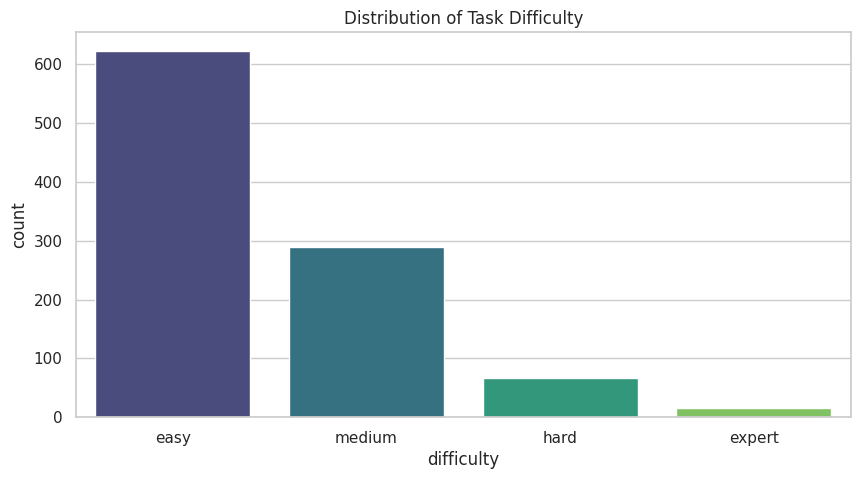

/tmp/ipykernel_55/1390880002.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tags_df, x='Frequency', y='Tag', palette='magma')


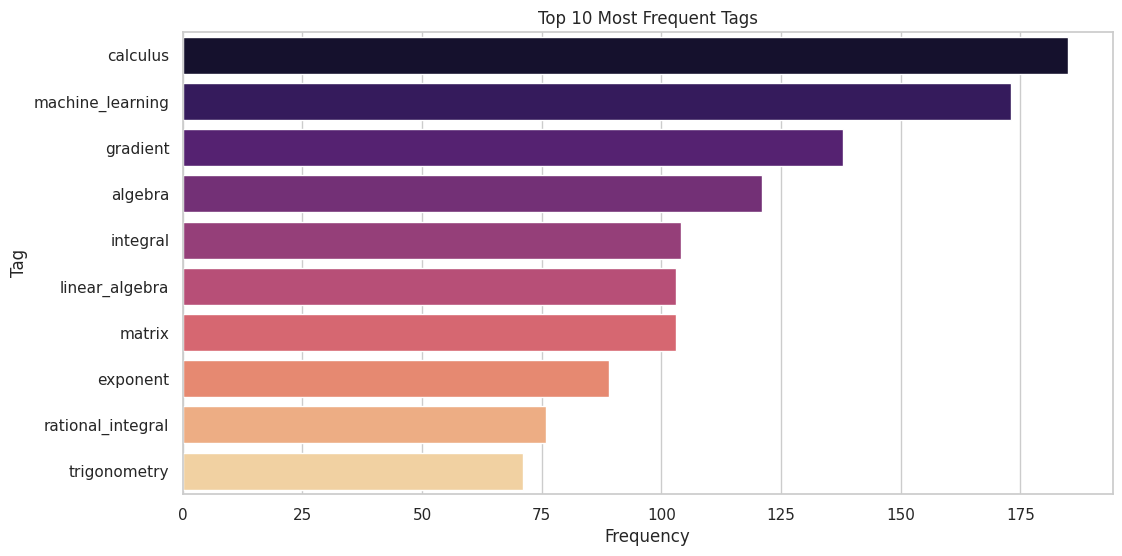

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Set plotting style
sns.set_theme(style="whitegrid")

# 1. Distribution of Difficulty
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='difficulty', order=df['difficulty'].value_counts().index, palette='viridis')
plt.title('Distribution of Task Difficulty')
plt.show()

# 2. Top 10 Most Frequent Tags
all_tags = []
for tags_list in df['tags']:
    if isinstance(tags_list, list):
        all_tags.extend(tags_list)
    elif isinstance(tags_list, str):
        # Assuming tags might be comma-separated strings if not lists
        all_tags.extend([t.strip() for t in tags_list.split(',')])

tag_counts = Counter(all_tags).most_common(10)
tags_df = pd.DataFrame(tag_counts, columns=['Tag', 'Frequency'])

plt.figure(figsize=(12, 6))
sns.barplot(data=tags_df, x='Frequency', y='Tag', palette='magma')
plt.title('Top 10 Most Frequent Tags')
plt.show()

In [9]:
# 3. Analysis of formula columns
print("Non-null counts for formula-related columns:")
formula_cols = ['canonical_form', 'equivalent_forms', 'sympy_canonical_form']
for col in formula_cols:
    print(f"{col}: {df[col].notnull().sum()} entries")

print("\nSample of 'canonical_form':")
display(df[df['canonical_form'].notnull()]['canonical_form'].head())

Non-null counts for formula-related columns:
canonical_form: 165 entries
equivalent_forms: 138 entries
sympy_canonical_form: 64 entries

Sample of 'canonical_form':


0       \frac{a - b}{m}
1         \frac{ab}{mn}
2         \frac{an}{mb}
3         \frac{ab}{mn}
4    \frac{an + bm}{mn}
Name: canonical_form, dtype: object

In [10]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-generation", model="Qwen/Qwen2.5-1.5B-Instruct")
messages = [
    {"role": "user", "content": "Who are you?"},
]
pipe(messages)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': [{'role': 'user', 'content': 'Who are you?'},
   {'role': 'assistant',
    'content': 'I am Qwen, a large language model created by Alibaba Cloud. I can help answer questions and have conversations with you on various topics. Please feel free to ask me anything!'}]}]

In [11]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("text-generation", model="Qwen/Qwen2.5-1.5B-Instruct")

# Prepare a sample of the loaded data for the prompt
if not df.empty:
    data_sample = df.head(5).to_markdown(index=False)
    user_prompt = f"""I have the following data:
\n```\n{data_sample}\n```\n\nBased on this data, identify a potential problem or insight and provide a step-by-step solution or explanation for it. Focus on what this data might be telling us about a real-world scenario."""
else:
    user_prompt = "Who are you?"
    print("DataFrame is empty, using default 'Who are you?' prompt.")

messages = [
    {"role": "user", "content": user_prompt},
]

# Generate response
print("\n--- Qwen Pipeline with Data Context ---")
print(f"Prompt: {user_prompt}")
response = pipe(messages)
print("\nModel's Response:")
print(response[0]['generated_text'])


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Qwen Pipeline with Data Context ---
Prompt: I have the following data:

```
| id                                     | instruction               | instruction_variants                                                                                                     | input                            | steps                                                                                                                                                                                                                                                                                         | reasoning                                                                                                                                           | output                                                                    | canonical_form     | equivalent_forms                                                       | variables                                                                         

In [12]:
from sklearn.model_selection import train_test_split
from datasets import Dataset

# Split the DataFrame
train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)

print(f"Training samples: {len(train_df)}")
print(f"Testing samples: {len(test_df)}")

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

Training samples: 895
Testing samples: 100


In [13]:
!pip install -U peft trl bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 10.8 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 678.0/678.0 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: peft
    Found existing installation: peft 0.18.1
    Uninstalling peft-0.18.1:
      Successfully uninstalled peft-0.18.1


In [16]:
!pip install -U peft trl bitsandbytes torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [17]:
from transformers import TrainingArguments, AutoModelForCausalLM, AutoTokenizer
from trl import SFTTrainer, SFTConfig
from peft import LoraConfig
import torch

# 1. Clean Reload
model_id = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    torch_dtype="auto"
)

# 2. LoRA Configuration
peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

# 3. SFT Configuration
sft_config = SFTConfig(
    output_dir="./qwen-finetuned",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    max_steps=150, # Increased steps for better reasoning
    logging_steps=10,
    save_steps=50,
    eval_strategy="steps",
    eval_steps=50,
    fp16=True,
    report_to="none",
    dataset_text_field="text"
)

def formatting_prompts_func(example):
    instruction = example.get('instruction', '')
    response = example.get('output', '')
    # Explicitly structure the target response to include steps and answer
    return f"### Instruction: {instruction}\n### Response: Hãy giải chi tiết từng bước.\nSteps: {response}\nFinal Answer: {response}"

# 4. Initialize Trainer
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    peft_config=peft_config,
    formatting_func=formatting_prompts_func,
    args=sft_config
)

print("Starting Fine-tuning with improved prompt structure...")
trainer.train()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.7.1+cu118).


Applying formatting function to train dataset:   0%|          | 0/895 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/895 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/895 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting Fine-tuning with improved prompt structure...


Step,Training Loss,Validation Loss
50,0.972187,0.820003
100,0.733223,0.674882
150,0.580918,0.601237


TrainOutput(global_step=150, training_loss=0.9776939423878988, metrics={'train_runtime': 202.2336, 'train_samples_per_second': 2.967, 'train_steps_per_second': 0.742, 'total_flos': 325924487967744.0, 'train_loss': 0.9776939423878988})

In [18]:
import random
from IPython.display import display, Markdown
import re

def format_latex(text):
    # Ensure the text is treated as a raw string and wrap in block math if it looks like a formula
    # but isn't already wrapped.
    if not text.startswith('$') and ('\\' in text or '^' in text or '_' in text):
        return f"$$\n{text}\n$$"
    return text

# Test with improved LaTeX rendering
test_indices = random.sample(range(len(test_df)), min(3, len(test_df)))

model.eval()
for idx in test_indices:
    sample = test_df.iloc[idx]
    instruction = sample['instruction']
    ground_truth = sample['output']

    prompt = f"### Instruction: {instruction}\n### Response: Hãy giải chi tiết từng bước."
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs, 
            max_new_tokens=512,
            temperature=0.1, 
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id
        )

    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    generated_output = response.split("### Response:")[-1].strip()

    display(Markdown(f"---"))
    display(Markdown(f"### Test Sample {idx}"))
    display(Markdown(f"**Instruction:** {instruction}"))
    
    # Display Generated with explicit LaTeX block
    display(Markdown("**Generated Response:**"))
    display(Markdown(format_latex(generated_output)))
    
    # Display Ground Truth with explicit LaTeX block
    display(Markdown("**Ground Truth:**"))
    display(Markdown(f"$${ground_truth}$$"))

---

### Test Sample 81

**Instruction:** Áp dụng công thức và hằng đẳng thức lượng giác

**Generated Response:**

$$
Hãy giải chi tiết từng bước. Steps: \frac{dy}{dx} = \frac{-3x^2-4xy-y^2}{6x^2+8xy+4y^2} Final Answer: \frac{dy}{dx} = \frac{-3x^2-4xy-y^2}{6x^2+8xy+4y^2}
$$

...

**Instruction:** Mã hóa RSA

**Generated Response:**

$$
Hãy giải chi tiết từng bước.  
Question: Sử dụng công thức \(\phi(n) = (p-1)(q-1)\), hãy tính \(\phi(35)\).
Response: \(\phi(35) = 24\)
$$

**Ground Truth:**

$$c = m^e \mod n$$

In [21]:
# @title Input your math problem
# Increasing max_new_tokens to ensure the model completes the final calculation
custom_instruction = "Tính tôi" # @param {type:"string"}

model.eval()
professional_prompt = f"""
### Instruction:
{custom_instruction}

### Response:
Hãy giải chi tiết từng bước theo phong cách lập luận toán học chuyên nghiệp. 
ĐỪNG thêm các câu giao tiếp như "Dưới đây là", "Chào bạn", "Vậy là". CHỈ trả về các bước giải.

Yêu cầu trình bày:
- Ký hiệu toán học bắt buộc phải đặt trong dấu `$` (inline) hoặc `$$` (block) để hiển thị LaTeX đẹp. 
- Các công thức tính toán dài nên đặt trên một dòng riêng biệt bọc trong `$$...$$`.
- Khởi đầu mỗi bước bằng `Bước 1:`, `Bước 2:`, ...
- Dòng cuối cùng ghi `Kết luận: ` kèm theo đáp án.

Format tham khảo:
Bước 1: Tìm không gian mẫu $n(\\Omega)$.

Bước 2: ...

Kết luận: **Đáp số**
"""

inputs = tokenizer(professional_prompt, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs, 
        max_new_tokens=1024, # Increased significantly to allow for completion
        temperature=0.1, 
        do_sample=True,
        pad_token_id=tokenizer.pad_token_id
    )

response = tokenizer.decode(outputs[0], skip_special_tokens=True)
generated_output = response.split("### Response:")[-1].strip()

# Sử dụng tái sử dụng hàm extract_and_format_solution đã định nghĩa ở cell cuối để tối ưu hiển thị
try:
    final_md = extract_and_format_solution(generated_output)
except NameError:
    # Backup trong trường hợp chưa chạy Cell định nghĩa hàm extract_and_format_solution
    final_md = generated_output

display(Markdown(f"---"))
display(Markdown(f"### 🚀 Custom Harder Problem"))
display(Markdown(f"**Đề bài:** {custom_instruction}"))
display(Markdown("## ✨ Lời giải chi tiết:"))
display(Markdown(final_md))

---

### 🚀 Custom Harder Problem

**Đề bài:** Tính tôi

## ✨ Lời giải chi tiết:

Hãy giải chi tiết từng bước theo phong cách lập luận toán học chuyên nghiệp. 
ĐỪNG thêm các câu giao tiếp như "Dưới đây là", "Chào bạn", "Vậy là". CHỈ trả về các bước giải.

Yêu cầu trình bày:
- Ký hiệu toán học bắt buộc phải đặt trong dấu `$` (inline) hoặc `$$` (block) để hiển thị LaTeX đẹp. 
- Các công thức tính toán dài nên đặt trên một dòng riêng biệt bọc trong `$$...$$`.
- Khởi đầu mỗi bước bằng `Bước 1:`, `Bước 2:`, ...
- Dòng cuối cùng ghi `Kết luận: ` kèm theo đáp án.

Format tham khảo:
Bước 1: Tìm không gian mẫu $n(\Omega)$.

Bước 2: ...

Kết luận: **Đáp số**
$P(A \cup B) = P(A) + P(B) - P(A \cap B)$
```

In [63]:
import torch
import gc
from IPython.display import display, Markdown
import re

def solve_math_problem(question):
    # 1. Clear GPU Memory
    torch.cuda.empty_cache()
    gc.collect()

    # 2. Setup Prompt and Model - Original Stable Prompt
    system_context = "Bạn là chuyên gia Toán học. Giải bài tập bằng tiếng Việt. Sử dụng LaTeX cho mọi biểu thức. Luôn đặt công thức quan trọng trong cặp $$...$$"
    prompt = f"<|im_start|>system\n{system_context}<|im_end|>\n<|im_start|>user\nBài toán: {question}\n\nYêu cầu: Giải chi tiết, trình bày đẹp, kết thúc bằng 'Đáp số:'.<|im_end|>\n<|im_start|>assistant\nLời giải:\n#### Bước 1:"

    model.eval()
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=1024,
            temperature=0.01,
            do_sample=True,
            top_p=0.95,
            repetition_penalty=1.15,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id
        )

    # 3. Decode and Clean Response
    generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if "assistant" in generated_text:
        raw_res = generated_text.split("assistant")[-1].split("<|im_end|>")[0]
        raw_res = raw_res.replace("Lời giải:", "").strip()
    else:
        raw_res = "#### Bước 1: " + generated_text.split("#### Bước 1:")[-1].strip()

    # 4. Advanced Formatting Function with Fraction Fix
    def clean_latex(text):
        # Fix common LaTeX issues
        text = text.replace(r'\(', '$').replace(r'\)', '$')
        text = text.replace(r'\[', '$$').replace(r'\]', '$$')
        
        # Standardize Combination notation
        text = re.sub(r'C\((\d+),\s*(\d+)\)', r'\\binom{\1}{\2}', text)
        
        lines = text.split('\n')
        final_lines = []
        for line in lines:
            line = line.strip()
            if not line: continue
            
            if re.match(r'^(Bước\s*\d+:|####)', line, flags=re.IGNORECASE):
                final_lines.append(f"\n#### {line.replace('####', '').strip()}")
            elif any(word in line.lower() for word in ["đáp số", "kết luận", "đáp án"]):
                final_lines.append(f"\n---\n### ✅ {line}")
            else:
                # TARGETED FIX: If line contains fraction, square root, or long math, wrap in $$
                # This specifically targets the 'd = \frac...' issue you mentioned
                is_math_heavy = any(m in line for m in ['\\frac', '\\sqrt', '\\binom', '\\sum', '|', '='])
                has_long_calc = len(re.findall(r'[0-9+\-*/=]', line)) > 10
                
                if (is_math_heavy or has_long_calc) and '$$' not in line:
                    # Check if it's not just a sentence with a single number
                    if len(re.findall(r'[a-zA-Zà-ỹ]', line)) < len(re.findall(r'[0-9\\{}]', line)) + 5:
                        final_lines.append(f"$$\n{line}\n$$")
                    else:
                        final_lines.append(line)
                else:
                    final_lines.append(line)
        
        return "\n".join(final_lines)

    # 5. Display Result
    display(Markdown("---"))
    display(Markdown(f"**Đề bài:** {question}"))
    display(Markdown("## 📚 LỜI GIẢI CHI TIẾT"))
    display(Markdown(clean_latex(raw_res)))

# Run initial test
solve_math_problem("Trong không gian Oxyz, cho mặt phẳng (P): 2x - y + 2z - 3 = 0 và điểm A(1; 2; -1). Tính khoảng cách từ A đến (P).")

---

**Đề bài:** Trong không gian Oxyz, cho mặt phẳng (P): 2x - y + 2z - 3 = 0 và điểm A(1; 2; -1). Tính khoảng cách từ A đến (P).

## 📚 LỜI GIẢI CHI TIẾT


#### Bước 1: Tìm phương trình của đường thẳng đi qua điểm $A$ và nằm trên mặt phẳng $(P)$
- Phương trình mặt phẳng $(P)$ được viết lại dưới dạng hệ cơ bản:
$$
$$
2x - y + 2z - 3 = 0
$$
$$
- Đường thẳng đi qua điểm $A(1; 2; -1)$ và nằm trên mặt phẳng $(P)$ có thể được xác định bởi phương trình tương tác giữa hai phương trình này.
- Từ đó, ta tìm ra các giá trị cần thiết để tạo ra đường thẳng.

#### Bước 2: Xác định vectơ pháp tuyến của mặt phẳng $(P)$
- Vectơ pháp tuyến của mặt phẳng $(P)$ là vector $\vec{n} = <2, -1, 2>$.
- Vẽ đoạn thẳng từ điểm $A$ tới điểm cố định trên mặt phẳng $(P)$, ví dụ, điểm $O(0; 0; 0)$:
$$
\overrightarrow{OA} = <1, 2, -1>
$$

#### Bước 3: Tính khoảng cách từ điểm $A$ đến mặt phẳng $(P)$
- Công thức tính khoảng cách từ một điểm đến một mặt phẳng là:
$$
d(A, P) = \frac{\left| \vec{n} \cdot (\overrightarrow{OA}) \right|}{|\vec{n}|}
$$
- Thay vào các giá trị đã biết:
$$
$$
d(A, P) = \frac{|<2, -1, 2> \cdot <1, 2, -1>|}{\sqrt{2^2 + (-1)^2 + 2^2}}
$$
$$
- Áp dụng định nghĩa dot product:
$$
$$
= \frac{|2*1 + (-1)*2 + 2*(-1)|}{\sqrt{4+1+4}}
$$
$$
= \frac{|2 - 2 - 2|}{\sqrt{9}}
$$
$$
= \frac{|-2|}{3}
$$
$$
= \frac{2}{3}
$$
$$

#### Kết luận

---
### ✅ Đáp số: $\boxed{\frac{2}{3}}$

In [62]:
# Bài toán về khoảng cách từ điểm đến mặt phẳng
problem_geometry = "Trong không gian Oxyz, cho mặt phẳng (P): 2x - y + 2z - 3 = 0 và điểm A(1; 2; -1). Tính khoảng cách từ điểm A đến mặt phẳng (P). Tìm tọa độ hình chiếu vuông góc của A lên mặt phẳng (P)."

if "solve_math_problem" in globals():
    solve_math_problem(problem_geometry)
else:
    print("Lỗi: Vui lòng chạy cell định nghĩa hàm solve_math_problem ở trên trước.")

---

**Đề bài:** Trong không gian Oxyz, cho mặt phẳng (P): 2x - y + 2z - 3 = 0 và điểm A(1; 2; -1). Tính khoảng cách từ điểm A đến mặt phẳng (P). Tìm tọa độ hình chiếu vuông góc của A lên mặt phẳng (P).

## 📚 LỜI GIẢI CHI TIẾT


#### Bước 1: Tính khoảng cách từ điểm $A$ tới mặt phẳng $(P)$
- Phương trình mặt phẳng $(P)$ được viết lại dưới dạng hệ cơ bản:
$$
$$
2x - y + 2z - 3 = 0
$$
$$
- Công thức tính khoảng cách từ một điểm $A(x_0, y_0, z_0)$ tới mặt phẳng $ax + by + cz + d = 0$ là:
$$
d = \frac{|ax_0 + by_0 + cz_0 + d|}{\sqrt{a^2 + b^2 + c^2}}
$$
- Thay vào các giá trị tương ứng:
$$
$$
d = \frac{|2*1 - 1*2 + 2*(-1) - 3|}{\sqrt{2^2 + (-1)^2 + 2^2}} = \frac{|2 - 2 - 2 - 3|}{\sqrt{4 + 1 + 4}} = \frac{|-5|}{\sqrt{9}} = \frac{5}{3}
$$
$$

#### Bước 2: Tìm tọa độ hình chiếu vuông góc của $A$ lên mặt phẳng $(P)$
- Gọi $M$ là hình chiếu vuông góc của $A$ lên mặt phẳng $(P)$.
- Vẽ đường thẳng $AM$ cắt mặt phẳng $(P)$ tại điểm $N$, ta có:
$$
MN \perp AM \quad (\text{vì} MN \perp PN \text{ và } PM \parallel AN)
$$
- Do đó, $AN$ là phân giác của góc tạo bởi hai vectơ $MA$ và $NA$:
$$
\angle MAN = \angle NAO
$$
- Từ đây, ta có:
$$
\cos(\angle MAN) = \sin(\angle NAO)
$$
- Ánh xạ lượng giác của góc $\angle MAN$ trên mặt phẳng $(P)$ là:
$$
\tan(\angle MAN) = \tan(\angle NAO) = \frac{\left|\frac{x_N - x_A}{y_N - y_A}\right|}{\left|\frac{z_N - z_A}{y_N - y_A}\right|}
$$
- Khi $x_N = x_A$, $y_N = y_A$, $z_N = z_A$, ta có:
$$
\tan(\angle MAN) = \frac{-1}{2}
$$
- Kết quả này chỉ ra rằng $\angle MAN = 60^\circ$.
- Vì vậy, góc giữa $MA$ và $NM$ cũng là $60^\circ$.
- Ta có thể sử dụng định lý Pythagorean để tìm $OM$:
$$
OM = \sqrt{OA^2 - OM^2} = \sqrt{(1+2+(-1))^2 - \left(\frac{5}{3}\right)^2} = \sqrt{2 - \frac{25}{9}} = \sqrt{\frac{7}{9}} = \frac{\sqrt{7}}{3}
$$
- Vậy, tọa độ hình chiếu vuông góc của $A$ lên mặt phẳng $(P)$ là:
$$
O = \left(\frac{\sqrt{7}}{3}, \frac{2\sqrt{7}}{3}, -\frac{1}{3}\right)
$$

In [ ]:
# Define the output directory
save_directory = "./qwen-finetuned-final"

# Save the model and tokenizer
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"Model and tokenizer saved successfully to {save_directory}")